In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import nltk

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

print("NLTK data ready!")

NLTK data ready!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sahil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sahil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sahil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = stopwords.words('english')

print("NLTK is working perfectly!")
print(f"Total stopwords: {len(stop_words)}")

NLTK is working perfectly!
Total stopwords: 198


In [4]:
# Load the datasets
fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')

# Check the shape
print("Fake News articles:", fake.shape)
print("Real News articles:", true.shape)

Fake News articles: (23481, 4)
Real News articles: (21417, 4)


In [5]:
# See first 5 rows of fake news
print("FAKE NEWS sample:")
fake.head()

FAKE NEWS sample:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
# See first 5 rows of real news
print("REAL NEWS sample:")
true.head()

REAL NEWS sample:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
# Check column names
print("Fake columns:", fake.columns.tolist())
print("true.columns:", true.columns.tolist())

# Check for missing values
print("\nMissing values in Fake:", fake.isnull().sum())
print("Missing values in True:", true.isnull().sum())


Fake columns: ['title', 'text', 'subject', 'date']
true.columns: ['title', 'text', 'subject', 'date']

Missing values in Fake: title      0
text       0
subject    0
date       0
dtype: int64
Missing values in True: title      0
text       0
subject    0
date       0
dtype: int64


In [8]:
# Add labels- Fake = 0, Real = 1
fake['label'] = 0
true['label'] = 1

# Combine both datasets into one
df = pd.concat([fake, true], ignore_index = True)

print("Total articles:", df.shape)
print(df['label'].value_counts())


Total articles: (44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64


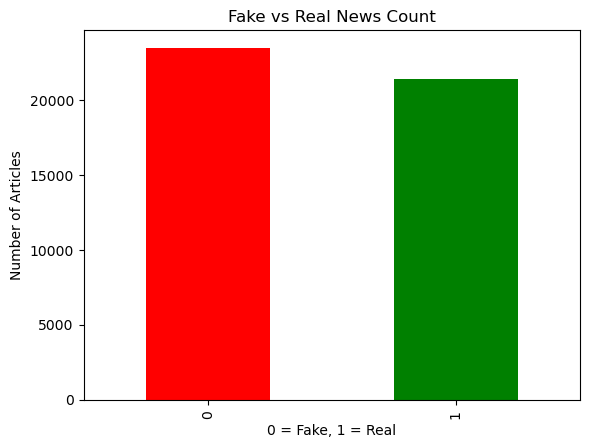

In [9]:
# Plot Fake vs Real news count
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Fake vs Real News Count')
plt.xlabel('0 = Fake, 1 = Real')
plt.ylabel('Number of Articles')
plt.show()

In [10]:
# Data Preprocessing
import re

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters 
    cleaned = ""
    for char in text:
        if char.isalpha() or char == " ":
            cleaned  += char
        else:
            cleaned += " "
    text = " ".join(cleaned.split())
    # Tokenize
    words = text.split()
    #Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

print("Text cleaning function created!")


Text cleaning function created!


In [11]:
# Apply cleaning function to the text column
df['clean_text'] = df['text'].apply(
    lambda x: ' '.join([
        lemmatizer.lemmatize(w)
        for w in str(x).lower().split()
        if w.isalpha() and w not in stop_words
    ])
)
print("Text cleaning done!")
print(df['clean_text'].head())


Text cleaning done!
0    donald trump wish american happy new year leav...
1    house intelligence committee chairman devin nu...
2    revealed former milwaukee sheriff david consid...
3    christmas donald trump announced would back wo...
4    pope francis used annual christmas day message...
Name: clean_text, dtype: object


In [12]:
# Feature Extraction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Define X and y
X = df['clean_text']
y = df['label']

# Split data - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Feature Extraction done!")
print("Training size:", X_train_tfidf.shape)
print("Testing size:", X_test_tfidf.shape)

Feature Extraction done!
Training size: (35918, 5000)
Testing size: (8980, 5000)


In [13]:
# Model Training
# Training all 4 Models

# Model 1 - Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
print("Naive Bayes trained!")

# Model 2 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
print("Logistic Regression trained!")

# Model 3 - Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_tfidf, y_train)
print("Decision Tree trained!")

# Model 4 - Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train_tfidf, y_train)
print("Random Forest trained!")

Naive Bayes trained!
Logistic Regression trained!
Decision Tree trained!
Random Forest trained!


In [14]:
# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest':rf_model
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

# Show best model
best_model = max(results, key=results.get)
print("\n Best Model:", best_model)
print("Best Accuracy:", results[best_model])



Naive Bayes
Accuracy: 0.9215
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      4733
           1       0.93      0.91      0.92      4247

    accuracy                           0.92      8980
   macro avg       0.92      0.92      0.92      8980
weighted avg       0.92      0.92      0.92      8980


Logistic Regression
Accuracy: 0.9736
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      4733
           1       0.97      0.97      0.97      4247

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980


Decision Tree
Accuracy: 0.9344
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      4733
           1       0.95      0.91      0.93      4247

    accuracy                           0.93      8980
   macro avg       0.94     

In [16]:
# Cross Validation
from sklearn.model_selection import cross_val_score
import numpy as np

print("=" * 50)
print("CROSS VALIDATION RESULTS (3-Fold)")
print("=" * 50)

# Using TF-IDF features
X_cv = tfidf.transform(df['clean_text'])
y_cv = df['label']

cv_models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=3, scoring='accuracy')
    print(f"\n{name}")
    print(f"Scores: {scores.round(4)}")
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print(f"Std Deviation: {scores.std():.4f}")

print("=" * 50)

CROSS VALIDATION RESULTS (3-Fold)

Naive Bayes
Scores: [0.8545 0.8452 0.899 ]
Mean Accuracy: 0.8663
Std Deviation: 0.0235

Logistic Regression
Scores: [0.9472 0.9275 0.9507]
Mean Accuracy: 0.9418
Std Deviation: 0.0102

Decision Tree
Scores: [0.8583 0.8869 0.8935]
Mean Accuracy: 0.8795
Std Deviation: 0.0153

Random Forest
Scores: [0.9661 0.9304 0.9522]
Mean Accuracy: 0.9496
Std Deviation: 0.0147


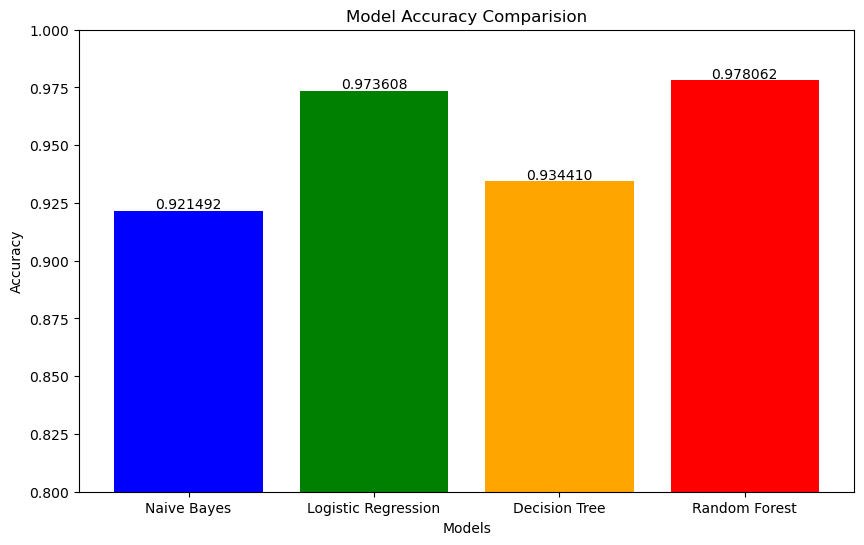

In [17]:
# Visualization
# Bar graph comparing all 4 models

model_names = ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, nb_model.predict(X_test_tfidf)),
    accuracy_score(y_test, lr_model.predict(X_test_tfidf)),
    accuracy_score(y_test, dt_model.predict(X_test_tfidf)),
    accuracy_score(y_test, rf_model.predict(X_test_tfidf))
]

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.title('Model Accuracy Comparision')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f'{v:4f}', ha='center')
plt.show()

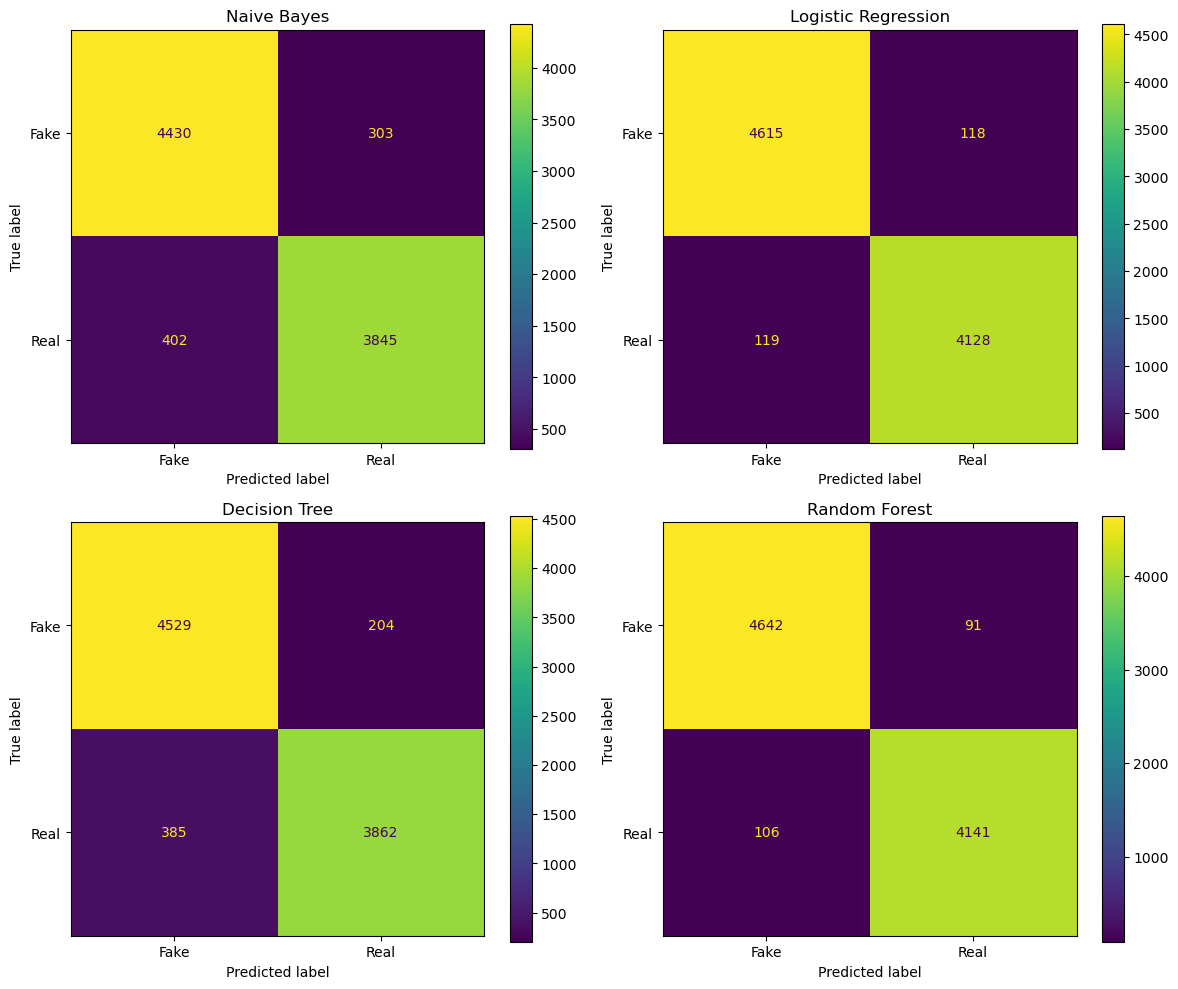

In [18]:
# Confusion Matrix for all 4 models
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_list = [
    ('Naive Bayes', nb_model),
    ('Logistic Regression', lr_model),
    ('Decision Tree', dt_model),
    ('Random Forest', rf_model)
]

for ax, (name, model) in zip(axes.flatten(), models_list):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
    disp.plot(ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

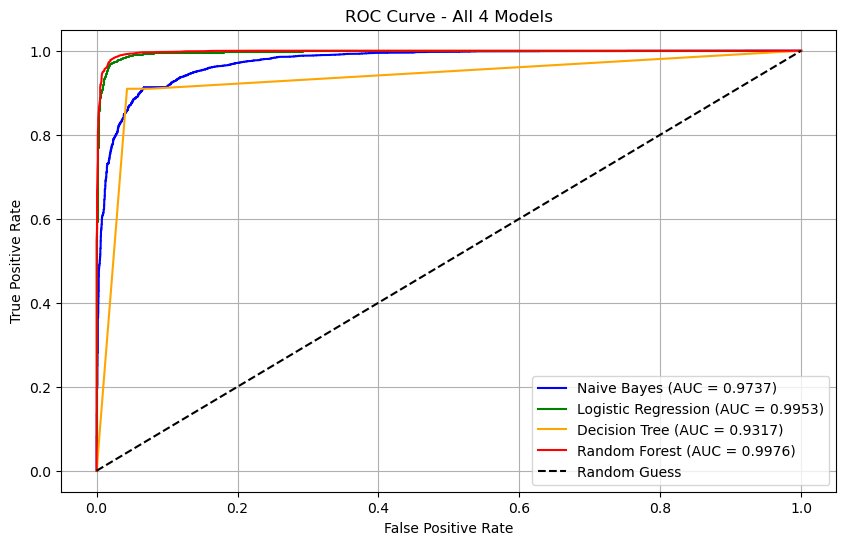

In [19]:
# ROC Curve for all 4 models
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

roc_models = {
    'Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

colors = ['blue', 'green', 'orange', 'red']

for (name, model), color in zip(roc_models.items(), colors):
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, 
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All 4 Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

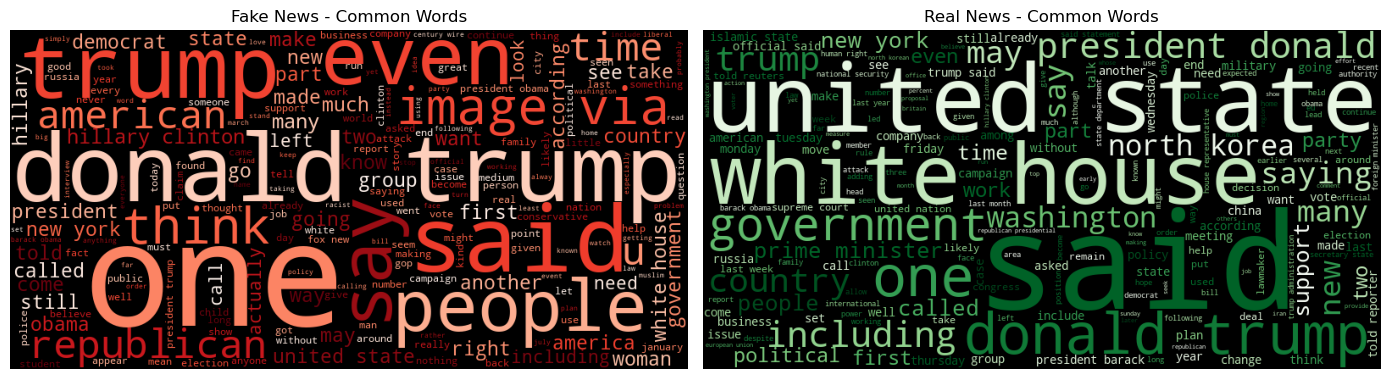

In [20]:
# Word Cloud for Fake and Real News 
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fake news word cloud
fake_words = ' '.join(df[df['label'] == 0]['clean_text'])
wordcloud_fake = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Reds'
).generate(fake_words)

axes[0].imshow(wordcloud_fake)
axes[0].set_title('Fake News - Common Words')
axes[0].axis('off')

# Real news word cloud
real_words = ' '.join(df[df['label'] == 1]['clean_text'])
wordcloud_real = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Greens'
).generate(real_words)

axes[1].imshow(wordcloud_real)
axes[1].set_title('Real News - Common Words')
axes[1].axis('off')

plt.tight_layout()
plt.show()

    

In [21]:
# Conclusion - Fake News Detection Final Results
print("=" * 55)
print("   FAKE NEWS DETECTION USING NLP & ML - RESULTS   ")
print("=" * 55)

results = {
    'Naive Bayes': 0.9215,
    'Logistic Regression': 0.9736,
    'Decision Tree': 0.9310,
    'Random Forest': 0.9785
}

for name, acc in results.items():
    print(f"{name:<22} {acc*100:.2f}%")

print("=" * 55)
print(" Best Model     : Random Forest")
print(" Best Accuracy  : 97.85%")
print(" Total Articles : 44,898")
print(" Test Size      : 8,980 articles")
print("=" * 55)
print("\n Conclusion:")
print("Random Forest achieved the highest accuracy of 97.85%")
print("for detecting fake news using TF-IDF features.")
print("Logistic Regression was a close second at 97.36%.")
print("Naive Bayes was fastest but least accurate at 92.15%.")
print("\n Limitation: Dataset is from 2017. Future work")
print("could explore more recent datasets and deep learning")
print("models like BERT for improved detection.")
print("=" * 55)

   FAKE NEWS DETECTION USING NLP & ML - RESULTS   
Naive Bayes            92.15%
Logistic Regression    97.36%
Decision Tree          93.10%
Random Forest          97.85%
 Best Model     : Random Forest
 Best Accuracy  : 97.85%
 Total Articles : 44,898
 Test Size      : 8,980 articles

 Conclusion:
Random Forest achieved the highest accuracy of 97.85%
for detecting fake news using TF-IDF features.
Logistic Regression was a close second at 97.36%.
Naive Bayes was fastest but least accurate at 92.15%.

 Limitation: Dataset is from 2017. Future work
could explore more recent datasets and deep learning
models like BERT for improved detection.


In [22]:
# Save models and tfidf vectorizer for streamlit app
import pickle

# Save TF-IDF
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save all 4 models
with open('nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('dt_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print(" All models saved successfully!")

 All models saved successfully!
